<a href="https://colab.research.google.com/github/ZenasEC/Orion-CNN-CIFAR10/blob/main/Eksperimen_CNN_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Memulai Skema C (Advanced) ---
Mengunduh dan menyiapkan dataset...
Memulai pelatihan model...
Epoch [1/15] -> Loss: 1.7035 | Accuracy: 37.68%
Epoch [2/15] -> Loss: 1.4189 | Accuracy: 48.86%
Epoch [3/15] -> Loss: 1.2949 | Accuracy: 53.41%
Epoch [4/15] -> Loss: 1.2052 | Accuracy: 56.88%
Epoch [5/15] -> Loss: 1.1445 | Accuracy: 59.16%
Epoch [6/15] -> Loss: 1.0827 | Accuracy: 61.45%
Epoch [7/15] -> Loss: 1.0428 | Accuracy: 62.91%
Epoch [8/15] -> Loss: 1.0102 | Accuracy: 64.42%
Epoch [9/15] -> Loss: 0.9830 | Accuracy: 65.03%
Epoch [10/15] -> Loss: 0.9504 | Accuracy: 66.56%
Epoch [11/15] -> Loss: 0.9304 | Accuracy: 67.33%
Epoch [12/15] -> Loss: 0.9063 | Accuracy: 67.76%
Epoch [13/15] -> Loss: 0.8896 | Accuracy: 68.49%
Epoch [14/15] -> Loss: 0.8681 | Accuracy: 69.28%
Epoch [15/15] -> Loss: 0.8574 | Accuracy: 69.70%
Pelatihan Selesai!

HASIL EVALUASI AKHIR UNTUK Skema C (Advanced)
Final Training Accuracy: 69.70%
Final Test/Validation Accuracy: 72.99%



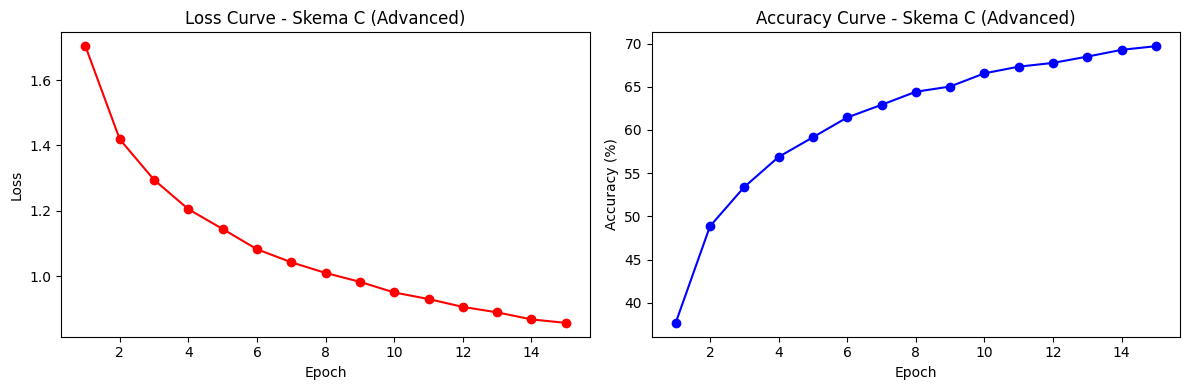

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# =====================================================================
# 1. KONFIGURASI EKSPERIMEN (Ubah BAGIAN INI saat ganti Skema!)
# =====================================================================
NAMA_SKEMA = "Skema C (Advanced)"  # Pilihan: "Skema A (Baseline)", "Skema B (Basic)", "Skema C (Advanced)"
BATCH_SIZE = 128
EPOCHS = 15  # Dosen biasanya meminta 15-30 epoch. Kita pasang 15 agar seimbang antara waktu & hasil.
LEARNING_RATE = 0.001

# Tentukan jenis augmentasi berdasarkan nama skema yang dipilih
if NAMA_SKEMA == "Skema A (Baseline)":
    transform_train = transforms.Compose([
        transforms.ToTensor(),
    ])
elif NAMA_SKEMA == "Skema B (Basic)":
    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
    ])
elif NAMA_SKEMA == "Skema C (Advanced)":
    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomCrop(32, padding=4),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomRotation(degrees=15),
        transforms.ToTensor(),
    ])

# Transformasi untuk data pengujian (Selalu bersih/tanpa augmentasi untuk semua skema)
transform_test = transforms.Compose([
    transforms.ToTensor(),
])

# =====================================================================
# 2. MEMUAT DATASET CIFAR-10
# =====================================================================
print(f"--- Memulai {NAMA_SKEMA} ---")
print("Mengunduh dan menyiapkan dataset...")
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# =====================================================================
# 3. MEMBUAT ARSITEKTUR CNN (Otak Buatan)
# =====================================================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Lapisan Konvolusi untuk menangkap fitur gambar (pola, bentuk, tepi)
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Ukuran jadi 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Ukuran jadi 8x8
        )
        # Lapisan Klasifikasi untuk menentukan kategori gambar (10 kelas)
        self.classifier = nn.Sequential(
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(-1, 64 * 8 * 8) # Meratakan matriks menjadi baris data tunggal
        x = self.classifier(x)
        return x

# Pindahkan model ke GPU agar proses training cepat
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Wadah untuk mencatat riwayat performa per putaran (epoch)
history_train_loss = []
history_train_acc = []

# =====================================================================
# 4. PROSES TRAINING (PELATIHAN MODEL)
# =====================================================================
print("Memulai pelatihan model...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device) # Transfer ke GPU

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100 * correct / total

    history_train_loss.append(epoch_loss)
    history_train_acc.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] -> Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

print("Pelatihan Selesai!")

# =====================================================================
# 5. EVALUASI OTOMATIS (MENGUJI PADA DATA BARU)
# =====================================================================
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

final_test_acc = 100 * test_correct / test_total
print("\n=============================================")
print(f"HASIL EVALUASI AKHIR UNTUK {NAMA_SKEMA}")
print(f"Final Training Accuracy: {history_train_acc[-1]:.2f}%")
print(f"Final Test/Validation Accuracy: {final_test_acc:.2f}%")
print("=============================================\n")

# =====================================================================
# 6. PEMBUATAN GRAFIK OTOMATIS
# =====================================================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), history_train_loss, marker='o', color='red')
plt.title(f'Loss Curve - {NAMA_SKEMA}')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), history_train_acc, marker='o', color='blue')
plt.title(f'Accuracy Curve - {NAMA_SKEMA}')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()